In [1]:
# Install Segment Anything and required libraries
!pip install opencv-python matplotlib
!pip install git+https://github.com/facebookresearch/segment-anything.git

# Install PyTorch (if not installed)
# Uncomment if needed
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-z7m4f896
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-z7m4f896
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=ff0111a68694345f1fa614ee531c8c42eec363fd19121c1e0418d01757748611
  Stored in directory: /tmp/pip-ephem-wheel-cache-iul8ud02/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
import torch


In [3]:
# Download pre-trained SAM model
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth


--2025-04-26 16:26:29--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.226.210.111, 13.226.210.25, 13.226.210.15, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.226.210.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   200MB/s    in 19s     

2025-04-26 16:26:48 (128 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [4]:
# Load the model
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)


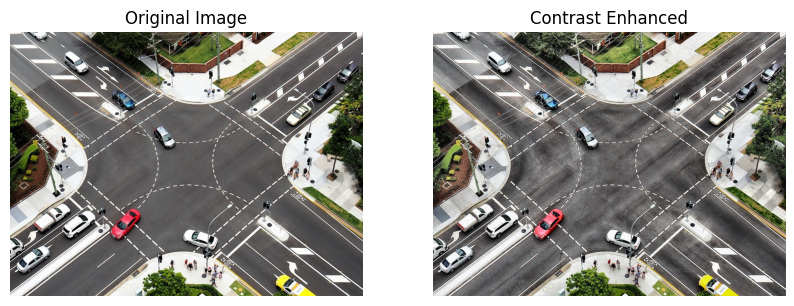

In [5]:
def contrast_enhancement(image):
    """Apply contrast enhancement using CLAHE."""
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l_channel, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l_channel)

    merged = cv2.merge((cl, a, b))
    enhanced_image = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

    return enhanced_image
# Load your input satellite image
input_image = cv2.imread('/content/traffic-5608291_960_720.jpg')  # or upload in colab

# Apply contrast enhancement
enhanced_image = contrast_enhancement(input_image)

# Display it
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(enhanced_image, cv2.COLOR_BGR2RGB))
plt.title('Contrast Enhanced')
plt.axis('off')
plt.show()


In [22]:
# Install Gradio if not installed
!pip install -q gradio

import gradio as gr
import numpy as np
import cv2
from segment_anything import SamPredictor, sam_model_registry
import torch

# -------- Load the SAM Model --------
sam_checkpoint = "sam_vit_h_4b8939.pth"  # <-- Your SAM checkpoint path
model_type = "vit_h"  # vit_h / vit_l
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

# -------- Define helper functions --------

def contrast_enhancement_bgr(image_bgr):
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    return enhanced

def segment_image_with_clicks(image, clicks):
    if image is None or clicks is None or len(clicks) == 0:
        return np.zeros((512, 512), dtype=np.uint8)

    # Prepare image
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image_bgr = contrast_enhancement_bgr(image_bgr)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    predictor.set_image(image_rgb)

    # Prepare points
    input_points = np.array([[click['x'], click['y']] for click in clicks])
    input_labels = np.array([1] * len(input_points))

    masks, scores, logits = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=False
    )

    final_mask = masks[0].astype(np.uint8) * 255
    return final_mask

def draw_points_on_image(image, clicks):
    img_copy = image.copy()
    for click in clicks:
        x, y = int(click['x']), int(click['y'])
        cv2.circle(img_copy, (x, y), radius=5, color=(255, 0, 0), thickness=-1)  # Red dot
    return img_copy

# -------- Build Gradio Interface --------

with gr.Blocks() as demo:
    gr.Markdown("# 🛣️ Point-based Road Segmentation using SAM (with point display)")

    with gr.Row():
        input_image = gr.Image(type="numpy", label="Upload Satellite Image")
        output_mask = gr.Image(type="numpy", label="Road Segmentation Mask")

    clicks_state = gr.State([])

    # ---- Modified on_click ----
    def on_click(img, evt: gr.SelectData, clicks):
        clicks.append({"x": evt.index[0], "y": evt.index[1]})
        updated_image = draw_points_on_image(img, clicks)
        return updated_image, clicks

    btn_segment = gr.Button("Segment Roads")

    input_image.select(on_click, [input_image, clicks_state], [input_image, clicks_state])  # <-- Update both
    btn_segment.click(segment_image_with_clicks, [input_image, clicks_state], output_mask)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://890f74bfc3716d5a49.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Install Gradio if not installed
!pip install -q gradio

import gradio as gr
import numpy as np
import cv2
from segment_anything import SamPredictor, sam_model_registry
import torch

# -------- Load the SAM Model --------
sam_checkpoint = "sam_vit_h_4b8939.pth"  # <-- Your SAM checkpoint path
model_type = "vit_h"  # vit_h / vit_l
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

# -------- Define helper functions --------

def contrast_enhancement_bgr(image_bgr):
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    return enhanced

def segment_image_with_clicks(image, clicks):
    if image is None or clicks is None or len(clicks) == 0:
        return np.zeros((512, 512), dtype=np.uint8)

    # Prepare image
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    image_bgr = contrast_enhancement_bgr(image_bgr)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    predictor.set_image(image_rgb)

    # Prepare points
    input_points = np.array([[click['x'], click['y']] for click in clicks])
    input_labels = np.array([1] * len(input_points))

    masks, scores, logits = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=False
    )

    final_mask = masks[0].astype(np.uint8) * 255
    return final_mask

def draw_points_on_image(image, clicks):
    img_copy = image.copy()
    for click in clicks:
        x, y = int(click['x']), int(click['y'])
        cv2.circle(img_copy, (x, y), radius=5, color=(255, 0, 0), thickness=-1)  # Red dot
    return img_copy

def clear_clicks(image):
    # Just return the original image without points
    return image, []

# -------- Build Gradio Interface --------

with gr.Blocks() as demo:
    gr.Markdown("# 🛣️ Point-based Road Segmentation using SAM (with point display & clear button)")

    with gr.Row():
        input_image = gr.Image(type="numpy", label="Upload Satellite Image")
        output_mask = gr.Image(type="numpy", label="Road Segmentation Mask")

    clicks_state = gr.State([])

    # ---- on_click updated ----
    def on_click(img, evt: gr.SelectData, clicks):
        clicks.append({"x": evt.index[0], "y": evt.index[1]})
        updated_image = draw_points_on_image(img, clicks)
        return updated_image, clicks

    btn_segment = gr.Button("Segment Roads")
    btn_clear = gr.Button("Clear Clicks")  # NEW BUTTON 🚮

    # Event Connections
    input_image.select(on_click, [input_image, clicks_state], [input_image, clicks_state])
    btn_segment.click(segment_image_with_clicks, [input_image, clicks_state], output_mask)
    btn_clear.click(clear_clicks, input_image, [input_image, clicks_state])  # Connect clear button!

demo.launch(share=True)


In [25]:
# Install Gradio if not installed
!pip install -q gradio

import gradio as gr
import numpy as np
import cv2
import torch
from segment_anything import SamPredictor, sam_model_registry

# -------- Load the SAM Model --------
sam_checkpoint = "sam_vit_h_4b8939.pth"  # <-- Your SAM checkpoint path
model_type = "vit_h"  # vit_h / vit_l
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

# -------- Helper Functions --------

def contrast_enhancement_bgr(image_bgr):
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    return enhanced

def apply_canny_edges(image_rgb):
    image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(image_gray, threshold1=100, threshold2=200)
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)  # Convert to 3 channels
    return edges_rgb

def segment_with_sam(canny_image_rgb, clicks):
    if canny_image_rgb is None or clicks is None or len(clicks) == 0:
        return np.zeros((512, 512), dtype=np.uint8)

    predictor.set_image(canny_image_rgb)

    input_points = np.array([[click['x'], click['y']] for click in clicks])
    input_labels = np.array([1] * len(input_points))

    masks, scores, logits = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=False
    )

    final_mask = masks[0].astype(np.uint8) * 255
    return final_mask

def draw_points(image, clicks):
    img_copy = image.copy()
    for click in clicks:
        x, y = int(click['x']), int(click['y'])
        cv2.circle(img_copy, (x, y), radius=5, color=(255, 0, 0), thickness=-1)
    return img_copy

def clear_clicks(image):
    return image, [], None

# -------- Gradio App --------

with gr.Blocks() as demo:
    gr.Markdown("# 🛣️ Method-2 (Modified): Canny Edges ➔ Click ➔ SAM Segmentation")

    with gr.Row():
        upload_image = gr.Image(type="numpy", label="Upload Satellite Image")
        edge_image_display = gr.Image(type="numpy", label="Canny Edge Image (Click Here)")

    with gr.Row():
        segmented_output = gr.Image(type="numpy", label="Road Segmentation Output")

    clicks_state = gr.State([])
    processed_canny_image = gr.State()

    def preprocess_image(image):
        if image is None:
            return None, None

        # Enhance contrast
        image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        enhanced = contrast_enhancement_bgr(image_bgr)
        enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

        # Apply Canny
        canny_rgb = apply_canny_edges(enhanced_rgb)

        return canny_rgb, canny_rgb  # output for display + hidden state

    def handle_click(img, evt: gr.SelectData, clicks):
        clicks.append({"x": evt.index[0], "y": evt.index[1]})
        updated_image = draw_points(img, clicks)
        return updated_image, clicks

    btn_segment = gr.Button("Segment Roads using SAM")
    btn_clear = gr.Button("Clear Points")

    upload_image.upload(preprocess_image, upload_image, [edge_image_display, processed_canny_image])

    edge_image_display.select(handle_click, [edge_image_display, clicks_state], [edge_image_display, clicks_state])

    btn_segment.click(segment_with_sam, [processed_canny_image, clicks_state], segmented_output)
    btn_clear.click(clear_clicks, edge_image_display, [edge_image_display, clicks_state, segmented_output])

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a9bf09f842e0965f48.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [31]:
# Install Gradio if not installed
!pip install -q gradio

import gradio as gr
import numpy as np
import cv2
import torch
from segment_anything import SamPredictor, sam_model_registry

# -------- Load the SAM Model --------
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

# -------- Helper Functions --------

def contrast_enhancement_bgr(image_bgr):
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

def high_pass_filter(image_rgb, kernel_size=3):
    blurred = cv2.GaussianBlur(image_rgb, (kernel_size, kernel_size), 0)
    high_pass = cv2.subtract(image_rgb, blurred)
    return high_pass

def classify_with_filter(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    # convert back to 3-channel so SAM .set_image works
    return cv2.cvtColor(thresh, cv2.COLOR_GRAY2RGB)

def segment_with_sam(classified_rgb, clicks):
    if classified_rgb is None or not clicks:
        return np.zeros(classified_rgb.shape[:2], dtype=np.uint8)
    predictor.set_image(classified_rgb)
    pts = np.array([[c['x'], c['y']] for c in clicks])
    labs = np.ones(len(pts), dtype=int)
    masks, _, _ = predictor.predict(point_coords=pts, point_labels=labs, multimask_output=False)
    return (masks[0].astype(np.uint8) * 255)

def draw_points(image, clicks):
    img = image.copy()
    for c in clicks:
        cv2.circle(img, (int(c['x']), int(c['y'])), 5, (255,0,0), -1)
    return img

def clear_clicks(img):
    return img, [], None

# -------- Gradio App --------

with gr.Blocks() as demo:
    gr.Markdown("## Method-3: Contrast → High-pass → Classification → SAM")

    with gr.Row():
        upload = gr.Image(type="numpy", label="Upload Satellite Image")
        hp_preview = gr.Image(type="numpy", label="High-pass Filtered")
        cls_preview = gr.Image(type="numpy", label="Classification (Threshold)")

    with gr.Row():
        seg_out = gr.Image(type="numpy", label="SAM Segmentation Mask")

    clicks = gr.State([])
    cls_state = gr.State()

    def preprocess(img):
        # enhance + high-pass + classify
        bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        enhanced = contrast_enhancement_bgr(bgr)
        enh_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)
        hp = high_pass_filter(enh_rgb)
        cls = classify_with_filter(hp)
        return hp, cls, cls  # show hp, show cls, store cls in state

    def on_click_class(img, evt: gr.SelectData, clicks):
        clicks.append({"x":evt.index[0],"y":evt.index[1]})
        return draw_points(img, clicks), clicks

    upload.upload(preprocess, upload, [hp_preview, cls_preview, cls_state])

    # attach clicks to classification preview
    cls_preview.select(on_click_class, [cls_preview, clicks], [cls_preview, clicks])

    gr.Button("Segment").click(segment_with_sam, [cls_state, clicks], seg_out)
    gr.Button("Clear").click(clear_clicks, cls_preview, [cls_preview, clicks, seg_out])

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://500161e012bb7e2d1f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [34]:
# Install Gradio if not installed
!pip install -q gradio

import gradio as gr
import numpy as np
import cv2
import torch
from segment_anything import SamPredictor, sam_model_registry

# -------- Load the SAM Model --------
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

# -------- Helper Functions --------

def contrast_enhancement_bgr(image_bgr):
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

def high_pass_filter(image_rgb, kernel_size=3):
    blurred = cv2.GaussianBlur(image_rgb, (kernel_size,kernel_size), 0)
    return cv2.subtract(image_rgb, blurred)

def segment_with_sam(hp_rgb, clicks):
    if hp_rgb is None or not clicks:
        return np.zeros(hp_rgb.shape[:2], dtype=np.uint8)
    predictor.set_image(hp_rgb)
    pts = np.array([[c['x'],c['y']] for c in clicks])
    labs = np.ones(len(pts), dtype=int)
    masks, _, _ = predictor.predict(point_coords=pts, point_labels=labs, multimask_output=False)
    return (masks[0].astype(np.uint8)*255)

def draw_points(img, clicks):
    out = img.copy()
    for c in clicks:
        cv2.circle(out, (int(c['x']),int(c['y'])), 5, (255,0,0), -1)
    return out

def clear_clicks(img):
    return img, [], None

# -------- Gradio App --------

with gr.Blocks() as demo:
    gr.Markdown("## Method-5: Contrast → High-pass → Click on HP → SAM")

    with gr.Row():
        upload = gr.Image(type="numpy", label="Upload Satellite Image")
        filtered_preview = gr.Image(type="numpy", label="High-pass Filtered Image")
    with gr.Row():
        seg_out = gr.Image(type="numpy", label="Road Segmentation Mask")

    clicks = gr.State([])
    hp_state = gr.State()

    # preprocess: produce HP image and store in state
    def preprocess(img):
        bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        enh = contrast_enhancement_bgr(bgr)
        enh_rgb = cv2.cvtColor(enh, cv2.COLOR_BGR2RGB)
        hp = high_pass_filter(enh_rgb)
        return hp, hp  # display hp, store hp_state

    # click handler on HP image
    def on_click_hp(hp_img, evt: gr.SelectData, clicks):
        clicks.append({"x":evt.index[0],"y":evt.index[1]})
        return draw_points(hp_img, clicks), clicks

    upload.upload(preprocess, upload, [filtered_preview, hp_state])
    filtered_preview.select(on_click_hp, [filtered_preview, clicks], [filtered_preview, clicks])
    gr.Button("Segment Roads").click(segment_with_sam, [hp_state, clicks], seg_out)
    gr.Button("Clear Points").click(clear_clicks, filtered_preview, [filtered_preview, clicks, seg_out])

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ffac981ca00e1ead41.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
